In [ ]:

# Machine Learning Task: Customer Churn Prediction (Classification)





Problem Statement
Customer churn is a major concern for businesses, especially in industries like telecom,
banking, and SaaS. Losing customers leads to revenue loss and increased acquisition costs.
In this project, the goal is to build a Machine Learning classification model that predicts
whether a customer will leave the company (Churn: Yes/No) based on features such as:
● Customer Age
● Gender
● Tenure
● Monthly Charges
● Total Charges
● Contract Type
● Payment Method
● Internet Service
● Tech Support
● Online Security
● Customer Support Calls

In [1]:
#Import Libraries - step 1
#Used for data handling, visualization, and ML models

!pip install xgboost imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

In [39]:
#Load Dataset - step 2

df = pd.read_csv('/content/telecom_churn_data (1).csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes


In [40]:
#Check Dataset - step 3
#Understand structure


print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7038 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non

In [41]:
#Handle Missing Values - step 4
#Clean null values

df.isnull().sum()
df.dropna(inplace=True)

In [42]:
#Remove Duplicates - step 5

df.drop_duplicates(inplace=True)

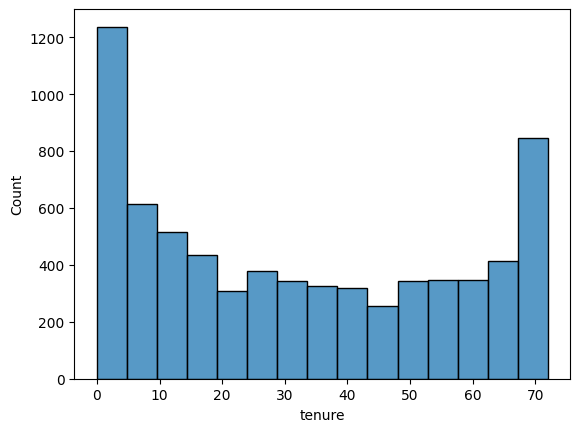

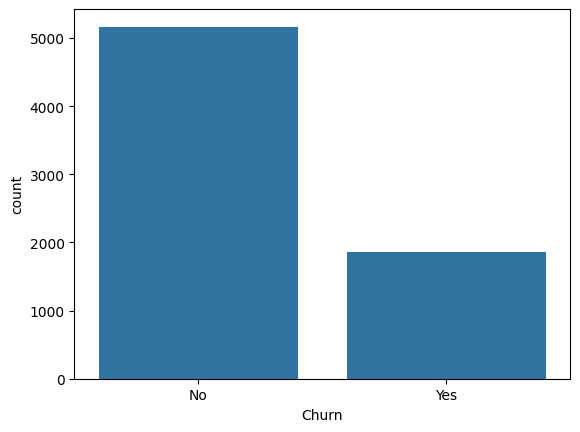

In [43]:
#Univariate Analysis - step 6
# Analyze single variables

sns.histplot(df['tenure'])
plt.show()

sns.countplot(x='Churn', data=df)
plt.show()

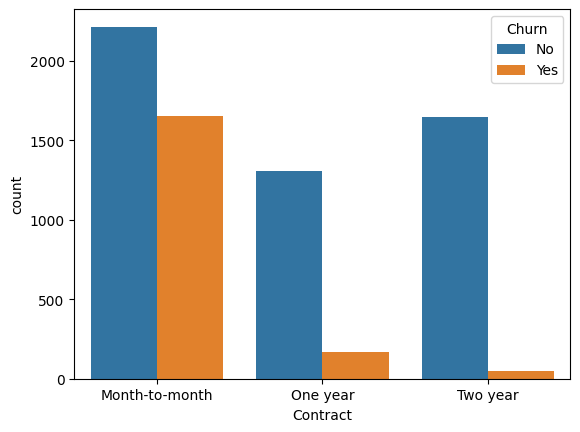

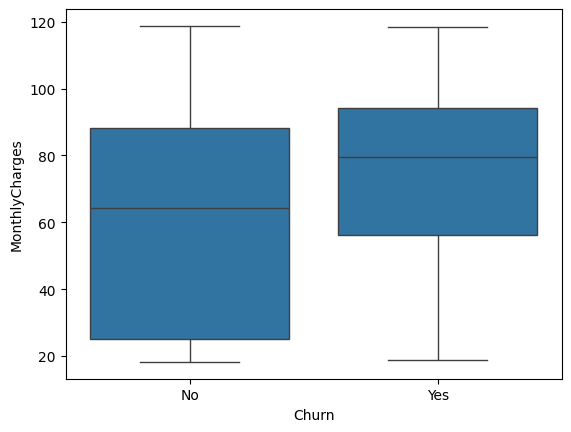

In [44]:
#Bivariate Analysis - step 7
#Relationship with churn

sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

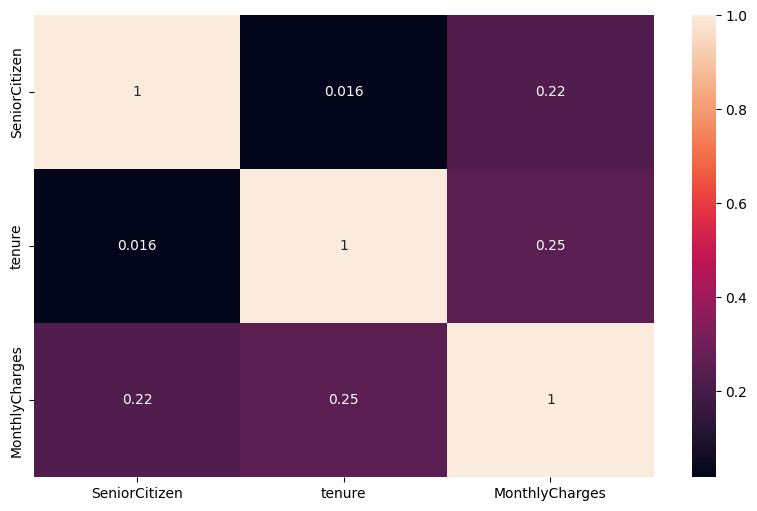

In [45]:
#Correlation Heatmap - step 8

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

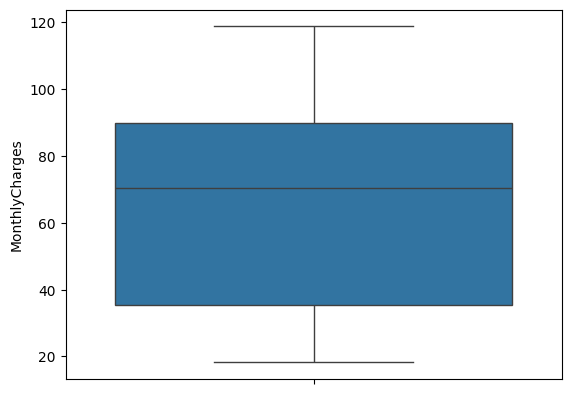

In [46]:
#Handle Outliers - step 9

sns.boxplot(df['MonthlyCharges'])
plt.show()

In [47]:
#Encoding - step 10
#Convert categorical → numeric

# Drop customerID as it's an identifier and not a feature
df = df.drop('customerID', axis=1, errors='ignore')

# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill NaN values in 'TotalCharges' (e.g., if there were empty strings or new customers with no charges)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop any remaining rows with NaN values after all specific handling
# This also serves as a final check, though initial NaNs should be gone from step 4
df.dropna(inplace=True)

# Diagnostic: Check for NaNs immediately after dropping
print("NaNs after df.dropna():\n", df.isnull().sum())

le = LabelEncoder()

# Apply LabelEncoder only to remaining object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

NaNs after df.dropna():
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [48]:
#Scaling - step 11

# First, separate features (X) and target (y) before scaling
X = df.drop('Churn', axis=1)
y = df['Churn']

# Diagnostic: Check for NaNs in X before scaling
print("NaNs in X before scaling:\n", X.isnull().sum())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Recreate X as a DataFrame with scaled values
X = pd.DataFrame(X_scaled, columns=X.columns)

NaNs in X before scaling:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


In [49]:
#Separate Features & Target - step 12

# This step is now implicitly handled in the previous scaling step (step 11).
# X and y are already defined and prepared for train-test split.

In [50]:
#Train-Test Split - step 13

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [51]:
#Handle Imbalance (SMOTE) - step 14

smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

In [52]:
#Train Models - step 15

models = {
    "Logistic": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Gradient Boost": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(name, "Accuracy:", acc)

Logistic Accuracy: 0.7526652452025586
KNN Accuracy: 0.673773987206823
Decision Tree Accuracy: 0.7157071783937455
Random Forest Accuracy: 0.7910447761194029
SVM Accuracy: 0.7562189054726368
Gradient Boost Accuracy: 0.7889125799573561
XGBoost Accuracy: 0.7931769722814499


              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1039
           1       0.60      0.61      0.60       368

    accuracy                           0.79      1407
   macro avg       0.73      0.73      0.73      1407
weighted avg       0.79      0.79      0.79      1407



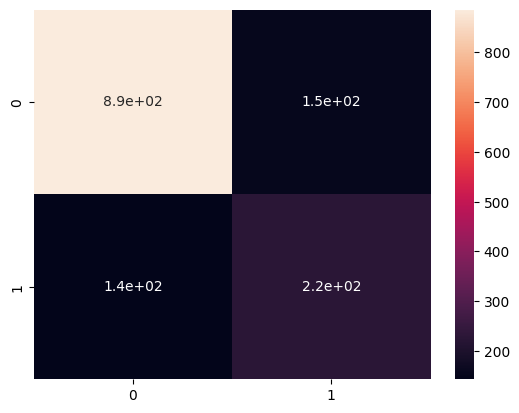

In [53]:
#Evaluation - step 16

best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.show()

In [54]:
#Hyperparameter Tuning - step 17

param_grid = {
    'n_estimators': [50,100],
    'max_depth': [5,10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 100}


In [55]:
#Best Model - step 18

best = max(results, key=results.get)
print("Best Model:", best)

Best Model: XGBoost
